# Machine Learning - Second Hand Car Price Prediction
---

## Import data and libraries

In [1]:
# base modules
from pathlib import Path
import logging
from collections import OrderedDict

# for manipulating data
import numpy as np
import pandas as pd
import math
from typing import Callable
import copy
import re
from pandas.api.types import is_string_dtype, is_numeric_dtype


# for Machine Learning
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn import metrics
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score, KFold, GridSearchCV

# for visualization
from matplotlib import pyplot as plt

import warnings
warnings.filterwarnings('ignore')

# for package auto reload
%load_ext autoreload
%autoreload 2

# for better rendering of plots in jupyter notebook
%matplotlib inline

In [2]:
import sys
import os
sys.path.append(os.path.abspath("../feature"))
from feature_engineering import outliers_proc, feature_engineering
from transform_to_log import transform_price_to_log
from process_data import fix_missing, process_df, numericalize, reduce_mem_usage


In [3]:
df=pd.read_csv('../data/used_car_train_20200313.csv', sep=' ')
testA=pd.read_csv('../data/used_car_testA_20200313.csv', sep=' ')

---
## Data Processing & Feature Engineering

In [4]:
df_log=transform_price_to_log(df, save_path='../user_data/price_log_transform.csv')
df_log=outliers_proc(df_log, 'power',scale=3)
df_fe=feature_engineering(df_log)

Saved to ../user_data/price_log_transform.csv
Delete number is: 963
Now row count is: 149037
Description of data less than the lower bound is:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: power, dtype: float64
Description of data larger than the upper bound is:
count      963.000000
mean       846.836968
std       1929.418081
min        376.000000
25%        400.000000
50%        436.000000
75%        514.000000
max      19312.000000
Name: power, dtype: float64


In [5]:
df_fe=reduce_mem_usage(df_fe)
continuous_feature_names = [x for x in df_fe.columns if x not in ['price_log','brand','model','brand']]
df_pr,y,nas=process_df(df_fe,'price_log')
print(df_pr.shape)
df_pr.head()

Memory usage of dataframe is 39345900.00 MB
Memory usage after optimization is: 10730796.00 MB
Decreased by 72.7%
(149037, 41)


,SaleID,name,model,brand,bodyType,fuelType,gearbox,power,kilometer,notRepairedDamage,...,power_bin,model_na,bodyType_na,fuelType_na,gearbox_na,notRepairedDamage_na,used_time_na,km_per_year_na,power_age_na,power_bin_na
0,0,736,30.0,6,1.0,0.0,0.0,60,12.5,0.0,...,5.0,False,False,False,False,False,False,False,False,False
1,1,2262,40.0,1,2.0,0.0,0.0,0,15.0,0.0,...,11.0,False,False,False,False,True,False,False,False,True
2,2,14874,115.0,15,1.0,0.0,0.0,163,12.5,0.0,...,16.0,False,False,False,False,False,False,False,False,False
3,3,71865,109.0,10,0.0,0.0,1.0,193,15.0,0.0,...,19.0,False,False,False,False,False,False,False,False,False
4,4,111080,110.0,5,1.0,0.0,0.0,68,5.0,0.0,...,6.0,False,False,False,False,False,False,False,False,False


In [6]:
len(y)
y

array([7.52348131, 8.18896686, 8.73600738, ..., 8.92279162, 8.51719319,
       8.45553053], shape=(149037,))

In [7]:
df_pr.columns

Index(['SaleID', 'name', 'model', 'brand', 'bodyType', 'fuelType', 'gearbox',
       'power', 'kilometer', 'notRepairedDamage', 'seller', 'offerType', 'v_0',
       'v_1', 'v_2', 'v_3', 'v_4', 'v_5', 'v_6', 'v_7', 'v_8', 'v_9', 'v_10',
       'v_11', 'v_12', 'v_13', 'v_14', 'used_time', 'city', 'km_per_year',
       'power_age', 'power_bin', 'model_na', 'bodyType_na', 'fuelType_na',
       'gearbox_na', 'notRepairedDamage_na', 'used_time_na', 'km_per_year_na',
       'power_age_na', 'power_bin_na'],
      dtype='object')

---

## Base model

In [8]:
y_series = pd.to_numeric(pd.Series(y), errors='coerce')
mask = y_series.notna()
X = df_pr.loc[mask].copy()

y = y_series.loc[mask].astype(float).to_numpy().ravel()

if X.isna().any().any():
    X = X.fillna(X.median(numeric_only=True))


print("X rows:", X.shape[0], "y rows:", y.shape[0], "X cols:", X.shape[1])
assert X.shape[0] == y.shape[0]

model = RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=10)
model.fit(X, y)


X rows: 149037 y rows: 149037 X cols: 41


,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


---
## Split Train & Validation set

In [9]:
n_total   = len(df_pr)          
n_test= n_total - len(y)  
X_labeled = df_pr.iloc[: n_total - n_test].copy() 
n_small = 30000


# do simple split
n_valid = 30000     
n_train = len(X_labeled) - n_valid

def split_vals(a, n):
    return a[:n].copy(), a[n:].copy()

# main splits
X_train, X_valid = split_vals(X_labeled, n_train)
y_train, y_valid = split_vals(y, n_train)

# small subset for fast experiments
X_small, _ = split_vals(X_train, n_small)
y_small, _ = split_vals(y_train, n_small)

# check sizes
print(f'Number of small training data points: X = {X_small.shape}, y = {y_small.shape}')
print(f'Number of full training data points: X = {X_train.shape}, y = {y_train.shape}')
print(f'Number of validation data points: X = {X_valid.shape}, y = {y_valid.shape}')

Number of small training data points: X = (30000, 41), y = (30000,)
Number of full training data points: X = (119037, 41), y = (119037,)
Number of validation data points: X = (30000, 41), y = (30000,)


In [10]:
X_train.columns

Index(['SaleID', 'name', 'model', 'brand', 'bodyType', 'fuelType', 'gearbox',
       'power', 'kilometer', 'notRepairedDamage', 'seller', 'offerType', 'v_0',
       'v_1', 'v_2', 'v_3', 'v_4', 'v_5', 'v_6', 'v_7', 'v_8', 'v_9', 'v_10',
       'v_11', 'v_12', 'v_13', 'v_14', 'used_time', 'city', 'km_per_year',
       'power_age', 'power_bin', 'model_na', 'bodyType_na', 'fuelType_na',
       'gearbox_na', 'notRepairedDamage_na', 'used_time_na', 'km_per_year_na',
       'power_age_na', 'power_bin_na'],
      dtype='object')

- define root mean squared error

In [11]:
def rmse(y_gold, y_pred): 
    return math.sqrt(((y_gold - y_pred)**2).mean())

- define print score(train/valid+oob)

In [13]:
def print_score(m, X_train, y_train, X_valid, y_valid, log_target=True):
    y_train_pred_log = m.predict(X_train)
    y_valid_pred_log = m.predict(X_valid)
    print('1. RMSE on train set (log_price): {:.4f}'.format(rmse(y_train, y_train_pred_log)))
    print('2. RMSE on valid set (log_price): {:.4f}'.format(rmse(y_valid, y_valid_pred_log)))
    print('3. MAE on train set (log_price): {:.4f}'.format(mean_absolute_error(y_train, y_train_pred_log)))
    print('4. MAE on valid set (log_price): {:.4f}'.format(mean_absolute_error(y_valid, y_valid_pred_log)))
    if log_target:
        y_train_real      = np.expm1(y_train)
        y_valid_real      = np.expm1(y_valid)
        y_train_pred_real = np.expm1(y_train_pred_log)
        y_valid_pred_real = np.expm1(y_valid_pred_log)
        print('5. R^2 on train set (original price): {:.4f}'.format(
            r2_score(y_train_real, y_train_pred_real)))
        print('6. R^2 on valid set (original price): {:.4f}'.format(
            r2_score(y_valid_real, y_valid_pred_real)))

    else:
        print('5. R^2 on train set: {:.4f}'.format(m.score(X_train, y_train)))
        print('6. R^2 on valid set: {:.4f}'.format(m.score(X_valid, y_valid)))
    if hasattr(m, 'oob_score_'):
        print('R^2 on oob set: {:.4f}'.format(m.oob_score_))

    return

---
## Training

- Small scale experiment

In [14]:
base_model = RandomForestRegressor(n_estimators=10, n_jobs=-1, random_state=10)
base_model.fit(X_small, y_small)
print_score(base_model, X_small, y_small, X_valid, y_valid)

1. RMSE on train set (log_price): 0.1154
2. RMSE on valid set (log_price): 0.2767
3. MAE on train set (log_price): 0.0655
4. MAE on valid set (log_price): 0.1651
5. R^2 on train set (original price): 0.9886
6. R^2 on valid set (original price): 0.9355


In [15]:
base_model = RandomForestRegressor(n_estimators = 10, n_jobs = -1, random_state = 10)

%time base_model.fit(X_train, y_train)
print_score(base_model, X_train, y_train, X_valid, y_valid)

CPU times: total: 30.4 s
Wall time: 4.14 s
1. RMSE on train set (log_price): 0.1087
2. RMSE on valid set (log_price): 0.2625
3. MAE on train set (log_price): 0.0584
4. MAE on valid set (log_price): 0.1483
5. R^2 on train set (original price): 0.9913
6. R^2 on valid set (original price): 0.9539


- Randomized splitting strategy

In [16]:
model = RandomForestRegressor(
    n_estimators = 100,
    max_depth = 20, 
    min_samples_split = 2,
    max_features = None,
    n_jobs = -1, 
    random_state = 10,
    
    bootstrap = True,
    oob_score = True, # default = False
    max_samples = None,
)


cv = KFold(n_splits = 5, shuffle = True, random_state = 10)

scores = cross_val_score(model, X_small, y_small, cv = cv, n_jobs = -1)
print(scores)
print("r2 is {:.3f} with a standard deviation of {:.3f}".format(scores.mean(), scores.std()))

[0.95248148 0.95460862 0.95429847 0.94989752 0.95336758]
r2 is 0.953 with a standard deviation of 0.002


---
## Hyperparmeter tuning

In [18]:
model.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': -1,
 'oob_score': False,
 'random_state': 10,
 'verbose': 0,
 'warm_start': False}

- Best model gird search

In [19]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [20, 30, None],
    'min_samples_split': [2, 4],
    'max_features': ['sqrt', 0.5],
    'max_samples': [0.8, None], 
}
model = RandomForestRegressor(
    random_state = 10,
    bootstrap = True,
    n_jobs=-1
)

In [20]:
tuned_model = GridSearchCV(
    estimator = model, 
    param_grid = param_grid, 
    scoring = None, # uses estimator's default score method
    n_jobs = -1, 
    refit = True, # keep a fitted version of the overall best model
    cv = 5, 
    return_train_score = True,
    verbose = 2,
)

In [ ]:
tuned_model.fit(X_small, y_small)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


In [44]:
best_model = tuned_model.best_estimator_
best_model

,n_estimators,200
,criterion,'squared_error'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,0.5
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [45]:
print_score(best_model, X_small, y_small, X_valid, y_valid)

- RMSE on train set (log_price): 0.0992
- RMSE on valid set (log_price): 0.2571
- MAE on train set (log_price): 0.0596
- MAE on valid set (log_price): 0.1540
1.R^2 on train set (original price): 0.9905
2.R^2 on valid set (original price): 0.9395
3.MAE on train set (original price): 279.07
4.MAE on valid set (original price): 715.23


In [54]:
%time best_model.fit(X_train, y_train)
print_score(best_model, X_train, y_train, X_valid, y_valid)

CPU times: total: 3min 5s
Wall time: 3min 8s
- RMSE on train set (log_price): 0.1092
- RMSE on valid set (log_price): 0.2403
- MAE on train set (log_price): 0.0629
- MAE on valid set (log_price): 0.1366
1.R^2 on train set (original price): 0.9917
2.R^2 on valid set (original price): 0.9585
3.MAE on train set (original price): 265.19
4.MAE on valid set (original price): 606.33


In [46]:
# randomized splitting strategy
cv = KFold(n_splits = 5, shuffle = True, random_state = 10)

scores = cross_val_score(best_model, X_small, y_small, cv = cv, n_jobs = -1)

print(scores)
print("r2 is {:.3f} with a standard deviation of {:.3f}".format(scores.mean(), scores.std()))

[0.95852871 0.95161404 0.95314477 0.94683181 0.95530534]
r2 is 0.953 with a standard deviation of 0.004


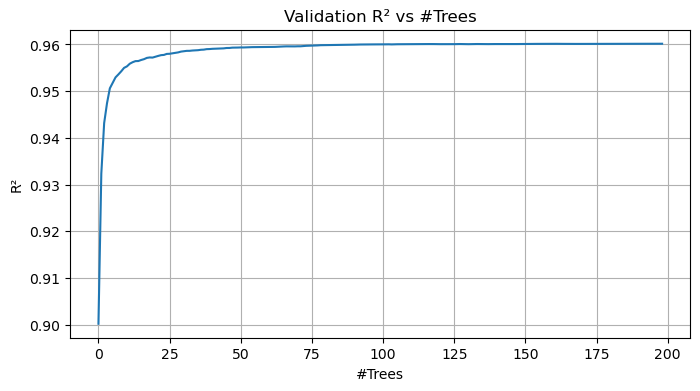

In [55]:
preds = np.stack([tree.predict(X_valid) for tree in best_model.estimators_]) # or np.asarray()

# predictions of the 10 trees, mean, and actual value (for first point in validation set)
preds.shape, preds[:,0], np.mean(preds[:,0]), y_valid[0]

plt.figure(figsize=(8,4))
plt.plot([
    metrics.r2_score(y_valid, np.mean(preds[:num_trees], axis=0))
    for num_trees in range(1, 200)
])
plt.title("Validation R² vs #Trees")
plt.xlabel("#Trees")
plt.ylabel("R²")
plt.grid(True)
plt.show()
plt.close()

In [47]:
import joblib

joblib.dump(best_model, '../user_data/best_model.joblib')

['../user_data/best_model.joblib']